# Phase 10 — Chaque mot interroge les autres

## Objectifs

- Coder le mécanisme d'attention, en une seule tête, entièrement à la main : seulement des tenseurs,
  des produits matriciels, un softmax, des couches linéaires. Aucun bloc tout prêt, rien qui porte déjà
  le mot « attention » dans son nom, aucune bibliothèque de modèle préentraîné.
- Partir d'un vrai relevé de la transmission, contenant au moins un pronom ou une reprise.
- Afficher la matrice des poids, lisible par un conseiller : les mots en étiquettes de lignes et de
  colonnes, pas un tableau de nombres bruts.
- Vérifier trois choses : chaque ligne de la matrice somme à 1, la sortie a la même forme que
  l'entrée, et on peut désigner la case qui dit sur quel mot s'appuie le pronom du relevé.


## 1. Imports

In [1]:
from pathlib import Path
import csv
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn


## 2. Configuration

In [2]:
SEED = 42
torch.manual_seed(SEED)

DEVICE = torch.device("cpu")
DATA_DIR = Path("../data")
OUTPUT_DIR = Path("../outputs")
PHASE10_DIR = OUTPUT_DIR / "phase_10_attention_a_la_main"
PHASE10_DIR.mkdir(parents=True, exist_ok=True)
DATA_PATH = DATA_DIR / "releves_klaxo3.csv"

COLUMNS = [
    "datetime", "city", "state", "country", "shape",
    "duration_seconds", "duration_hours_min", "comments",
    "date_posted", "latitude", "longitude",
]

D_MODEL = 32  # dimension des vecteurs question / etiquette / contenu, volontairement petite et lisible


## 3. Un vrai relevé, avec une reprise

On cherche, dans la transmission, un relevé de longueur raisonnable (pour que la figure reste
lisible) contenant un pronom qui reprend un objet cité plus tôt dans la même phrase.

In [3]:
lignes_valides = []
with open(DATA_PATH, "r", encoding="utf-8", errors="replace", newline="") as f:
    reader = csv.reader(f)
    for row in reader:
        if len(row) == len(COLUMNS):
            lignes_valides.append(row)
df = pd.DataFrame(lignes_valides, columns=COLUMNS)
df["comments_clean"] = df["comments"].fillna("").astype(str).str.strip()

def tokenizer(texte):
    return re.findall(r"[a-z0-9]+", str(texte).lower())

RELEVE_CHOISI_INDEX = 100
texte_choisi = df.loc[RELEVE_CHOISI_INDEX, "comments_clean"]
tokens = tokenizer(texte_choisi)

print(f"Relevé choisi (index {RELEVE_CHOISI_INDEX}) : {texte_choisi!r}")
print(f"Jetons ({len(tokens)}) : {tokens}")
print(f"Le pronom 'it' apparaît aux positions : {[i for i, t in enumerate(tokens) if t == 'it']}")


Relevé choisi (index 100) : 'Oval shaped with lights all around it in a haze with several smaller lights flying all around it.'
Jetons (18) : ['oval', 'shaped', 'with', 'lights', 'all', 'around', 'it', 'in', 'a', 'haze', 'with', 'several', 'smaller', 'lights', 'flying', 'all', 'around', 'it']
Le pronom 'it' apparaît aux positions : [6, 17]


## 4. Vecteurs d'entrée

Un vocabulaire construit sur ce seul relevé (suffisant pour la démonstration), un embedding par
jeton, initialisé aléatoirement — rien n'est entraîné à ce stade, on démontre un mécanisme, pas un
apprentissage.

In [4]:
vocabulaire = {"<UNK>": 0}
for token in tokens:
    if token not in vocabulaire:
        vocabulaire[token] = len(vocabulaire)

ids = torch.tensor([vocabulaire[t] for t in tokens], dtype=torch.long)

embedding = nn.Embedding(len(vocabulaire), D_MODEL)
vecteurs_entree = embedding(ids)  # (longueur, D_MODEL)

print(f"Forme des vecteurs d'entrée : {tuple(vecteurs_entree.shape)}")


Forme des vecteurs d'entrée : (18, 32)


## 5. Les trois rôles de chaque mot

Trois couches linéaires, sans biais, chacune projette le vecteur d'un mot dans son propre rôle :
question (ce qu'il cherche), étiquette (ce qu'il annonce), contenu (ce qu'il donne une fois choisi.)
Aucune de ces trois couches ne s'appelle « attention », ce sont des `nn.Linear` ordinaires.

In [5]:
couche_question = nn.Linear(D_MODEL, D_MODEL, bias=False)
couche_etiquette = nn.Linear(D_MODEL, D_MODEL, bias=False)
couche_contenu = nn.Linear(D_MODEL, D_MODEL, bias=False)

questions = couche_question(vecteurs_entree)   # (longueur, D_MODEL)
etiquettes = couche_etiquette(vecteurs_entree)  # (longueur, D_MODEL)
contenus = couche_contenu(vecteurs_entree)      # (longueur, D_MODEL)

print(f"questions : {tuple(questions.shape)} | etiquettes : {tuple(etiquettes.shape)} | contenus : {tuple(contenus.shape)}")


questions : (18, 32) | etiquettes : (18, 32) | contenus : (18, 32)


## 6. Le calcul, en trois lignes

Score de chaque mot contre chaque autre (produit matriciel des questions par les étiquettes,
transposées), divisé par la racine de la dimension pour ne pas saturer le softmax, transformé en
proportions qui somment à un, puis mélange pondéré des contenus.

In [6]:
scores = questions @ etiquettes.T / (D_MODEL ** 0.5)   # (longueur, longueur)
poids_attention = torch.softmax(scores, dim=-1)         # (longueur, longueur)
sortie = poids_attention @ contenus                      # (longueur, D_MODEL)

print(f"scores : {tuple(scores.shape)} | poids : {tuple(poids_attention.shape)} | sortie : {tuple(sortie.shape)}")


scores : (18, 18) | poids : (18, 18) | sortie : (18, 32)


## 7. La matrice des poids, lisible

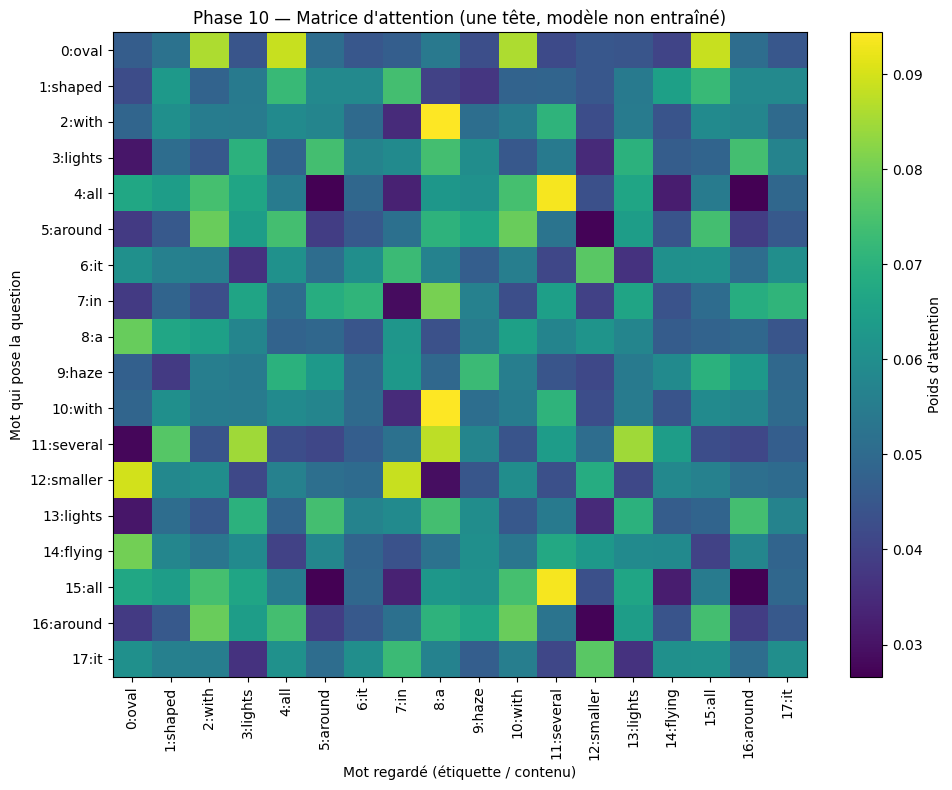

,0:oval,1:shaped,2:with,3:lights,4:all,5:around,6:it,7:in,8:a,9:haze,10:with,11:several,12:smaller,13:lights,14:flying,15:all,16:around,17:it
0:oval,0.047,0.052,0.086,0.045,0.089,0.051,0.045,0.047,0.054,0.043,0.086,0.042,0.045,0.045,0.040,0.089,0.051,0.045
1:shaped,0.042,0.063,0.048,0.054,0.072,0.059,0.059,0.074,0.040,0.037,0.048,0.049,0.045,0.054,0.065,0.072,0.059,0.059
2:with,0.049,0.060,0.055,0.055,0.059,0.057,0.050,0.035,0.094,0.051,0.055,0.071,0.043,0.055,0.044,0.059,0.057,0.050
3:lights,0.031,0.051,0.045,0.070,0.049,0.074,0.057,0.059,0.074,0.060,0.045,0.054,0.035,0.070,0.047,0.049,0.074,0.057
4:all,0.067,0.064,0.075,0.066,0.055,0.027,0.049,0.033,0.063,0.061,0.075,0.094,0.043,0.066,0.032,0.055,0.027,0.049
5:around,0.038,0.045,0.079,0.064,0.074,0.039,0.045,0.052,0.070,0.067,0.079,0.053,0.027,0.064,0.044,0.074,0.039,0.045
6:it,0.061,0.056,0.056,0.037,0.061,0.051,0.060,0.073,0.057,0.047,0.056,0.041,0.077,0.037,0.061,0.061,0.051,0.060
7:in,0.038,0.049,0.043,0.066,0.051,0.069,0.071,0.029,0.081,0.057,0.043,0.065,0.040,0.066,0.044,0.051,0.069,0.071
8:a,0.079,0.067,0.065,0.057,0.048,0.049,0.044,0.062,0.043,0.055,0.065,0.057,0.062,0.057,0.046,0.048,0.049,0.044
9:haze,0.047,0.038,0.056,0.054,0.070,0.063,0.050,0.063,0.049,0.073,0.056,0.045,0.041,0.054,0.059,0.070,0.063,0.050


In [7]:
matrice_poids = pd.DataFrame(
    poids_attention.detach().numpy(),
    index=[f"{i}:{t}" for i, t in enumerate(tokens)],
    columns=[f"{i}:{t}" for i, t in enumerate(tokens)],
)

plt.figure(figsize=(10, 8))
plt.imshow(matrice_poids.values, cmap="viridis", aspect="auto")
plt.colorbar(label="Poids d'attention")
plt.xticks(range(len(tokens)), matrice_poids.columns, rotation=90)
plt.yticks(range(len(tokens)), matrice_poids.index)
plt.xlabel("Mot regardé (étiquette / contenu)")
plt.ylabel("Mot qui pose la question")
plt.title("Phase 10 — Matrice d'attention (une tête, modèle non entraîné)")
plt.tight_layout()
plt.savefig(PHASE10_DIR / "matrice_attention.png", dpi=150)
plt.show()

matrice_poids.round(3)


## 8. Vérifications

In [8]:
sommes_lignes = poids_attention.sum(dim=1)
print("Chaque ligne somme à 1 :", torch.allclose(sommes_lignes, torch.ones_like(sommes_lignes), atol=1e-5))
print("Sommes des lignes (extrait) :", sommes_lignes[:5].tolist())

print(f"Forme de l'entrée : {tuple(vecteurs_entree.shape)}")
print(f"Forme de la sortie : {tuple(sortie.shape)}")
print("La sortie a la même forme que l'entrée :", tuple(vecteurs_entree.shape) == tuple(sortie.shape))


Chaque ligne somme à 1 : True
Sommes des lignes (extrait) : [1.0, 1.0, 0.9999998807907104, 1.0, 0.9999998807907104]
Forme de l'entrée : (18, 32)
Forme de la sortie : (18, 32)
La sortie a la même forme que l'entrée : True


## 9. Où le pronom s'appuie-t-il ?

Pour chaque position où le jeton est `it`, on lit la ligne correspondante de la matrice et on désigne
le mot dont l'étiquette a reçu le score le plus élevé.

In [9]:
positions_it = [i for i, t in enumerate(tokens) if t == "it"]

for position in positions_it:
    ligne = poids_attention[position]
    position_max = int(ligne.argmax())
    print(
        f"'it' en position {position} s'appuie le plus sur '{tokens[position_max]}' "
        f"(position {position_max}, poids {ligne[position_max]:.4f})"
    )

print(
    "\nLe modèle n'est pas entraîné (poids aléatoires) : cette case a probablement une valeur "
    "arbitraire, pas nécessairement 'oval', le mot que reprend réellement 'it'. Ce qui est démontré "
    "ici, c'est que le mécanisme SAIT désigner une case précise pour cette question — pas qu'il a déjà "
    "appris la bonne réponse."
)


'it' en position 6 s'appuie le plus sur 'smaller' (position 12, poids 0.0771)
'it' en position 17 s'appuie le plus sur 'smaller' (position 12, poids 0.0771)

Le modèle n'est pas entraîné (poids aléatoires) : cette case a probablement une valeur arbitraire, pas nécessairement 'oval', le mot que reprend réellement 'it'. Ce qui est démontré ici, c'est que le mécanisme SAIT désigner une case précise pour cette question — pas qu'il a déjà appris la bonne réponse.


## 10. Export

In [10]:
matrice_poids.to_csv(PHASE10_DIR / "matrice_attention.csv")

resume_phase10 = pd.DataFrame([{
    "index_releve": RELEVE_CHOISI_INDEX,
    "texte": texte_choisi,
    "nombre_jetons": len(tokens),
    "d_model": D_MODEL,
    "lignes_somment_a_un": bool(torch.allclose(sommes_lignes, torch.ones_like(sommes_lignes), atol=1e-5)),
    "forme_entree": str(tuple(vecteurs_entree.shape)),
    "forme_sortie": str(tuple(sortie.shape)),
    "positions_it": str(positions_it),
}])
resume_phase10.to_csv(PHASE10_DIR / "resume_phase10.csv", index=False)
resume_phase10


,index_releve,texte,nombre_jetons,d_model,lignes_somment_a_un,forme_entree,forme_sortie,positions_it
0,100,Oval shaped with lights all around it in a haz...,18,32,True,"(18, 32)","(18, 32)","[6, 17]"
